# yfinance Library Assignment  

In [22]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

### Function Specification: `download_historical_data`

Implement the function `download_historical_data` to fetch historical price data using Yahoo Finance as the data source. This function should be capable of fetching historical data for a specified stock symbol between given start and end dates. Additionally, it should support an optional parameter for the data timeframe with a default value of `'1d'` (daily).

---

### Function Specifications

**Parameters:**
- `symbol`: The ticker symbol of the stock (e.g., `'RELIANCE.NS'`).
- `start_date`: Start date for the data in `'YYYY-MM-DD'` format.
- `end_date`: End date for the data in `'YYYY-MM-DD'` format.
- `timeframe`: The frequency of the data (`'1d'`, `'1wk'`, `'1mo'`), default is `'1d'`.

**Return:**  
A pandas `DataFrame` containing the fetched data.


In [23]:
def download_historical_data(symbol, start_date, end_date, timeframe='1d'): 
    data = yf.download(symbol,start=start_date,end=end_date,interval=timeframe)
    data.dropna(inplace=True)
    return data


### Visualization

Create a function for plotting the stock closing prices. This function should accept parameters for the plot and its objective is to display the graph.
   


In [24]:
def plt_closing_price(dataframes,labels, title='Stock Closing Prices'):
    plt.figure(figsize=(16,8))
    for data, label in zip(dataframes,labels):
        plt.plot(data.index,data['Close'],label=label)
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Closing Price (INR)')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Run the functions

**Choose Stocks:**  
   - Select any three stocks of your choice.
   - Fetch their data for the time period from **2012 to 2022**.
   - Select daily time frame i.e. 1d.

**Plot the Data:**  
   1. Plot the data for each stock separately.  
   2. Combine the data and plot all three stocks on the **same graph** for comparison.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


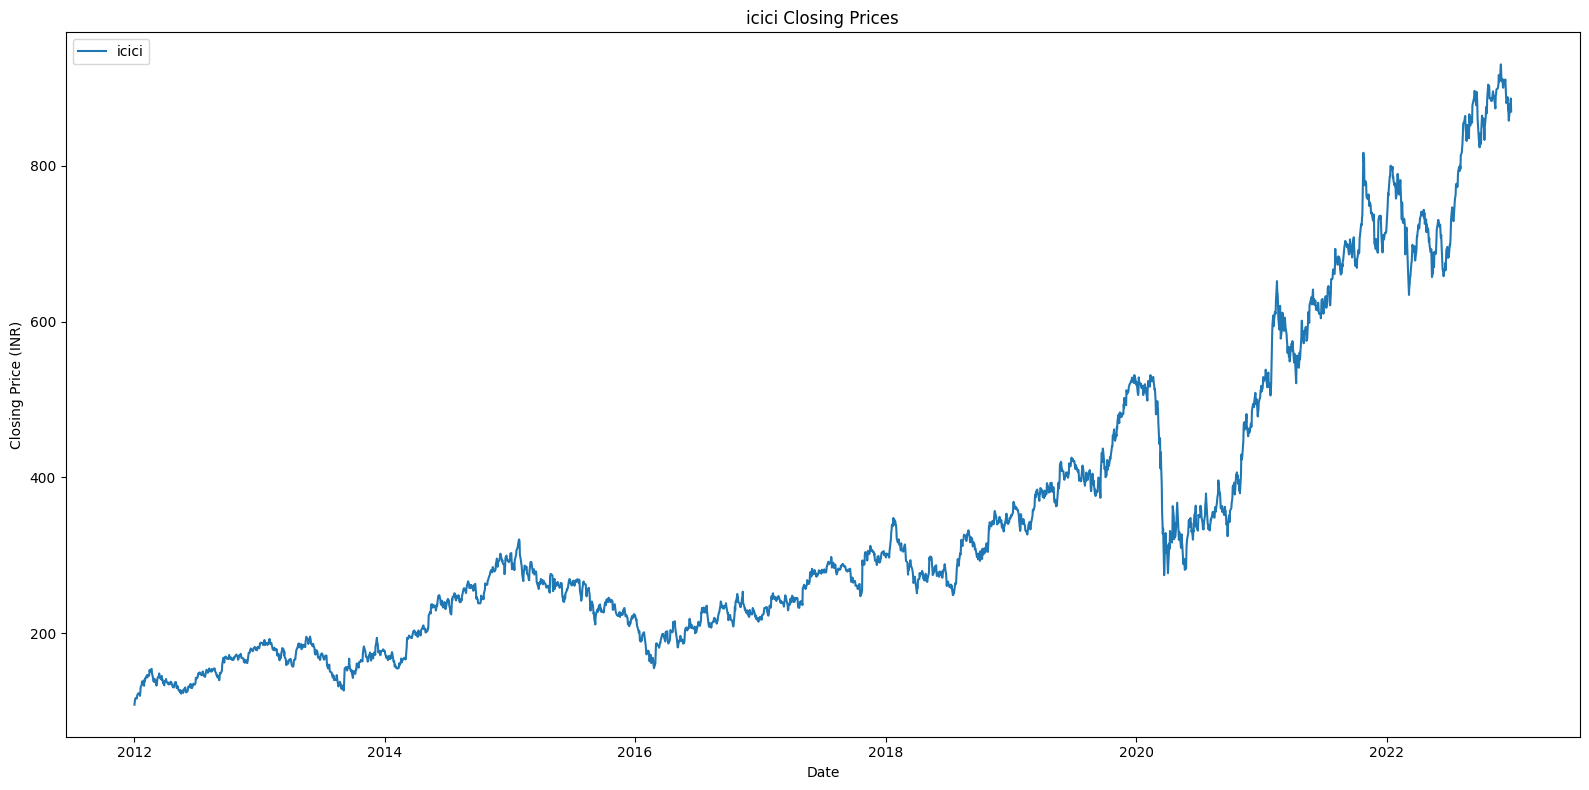

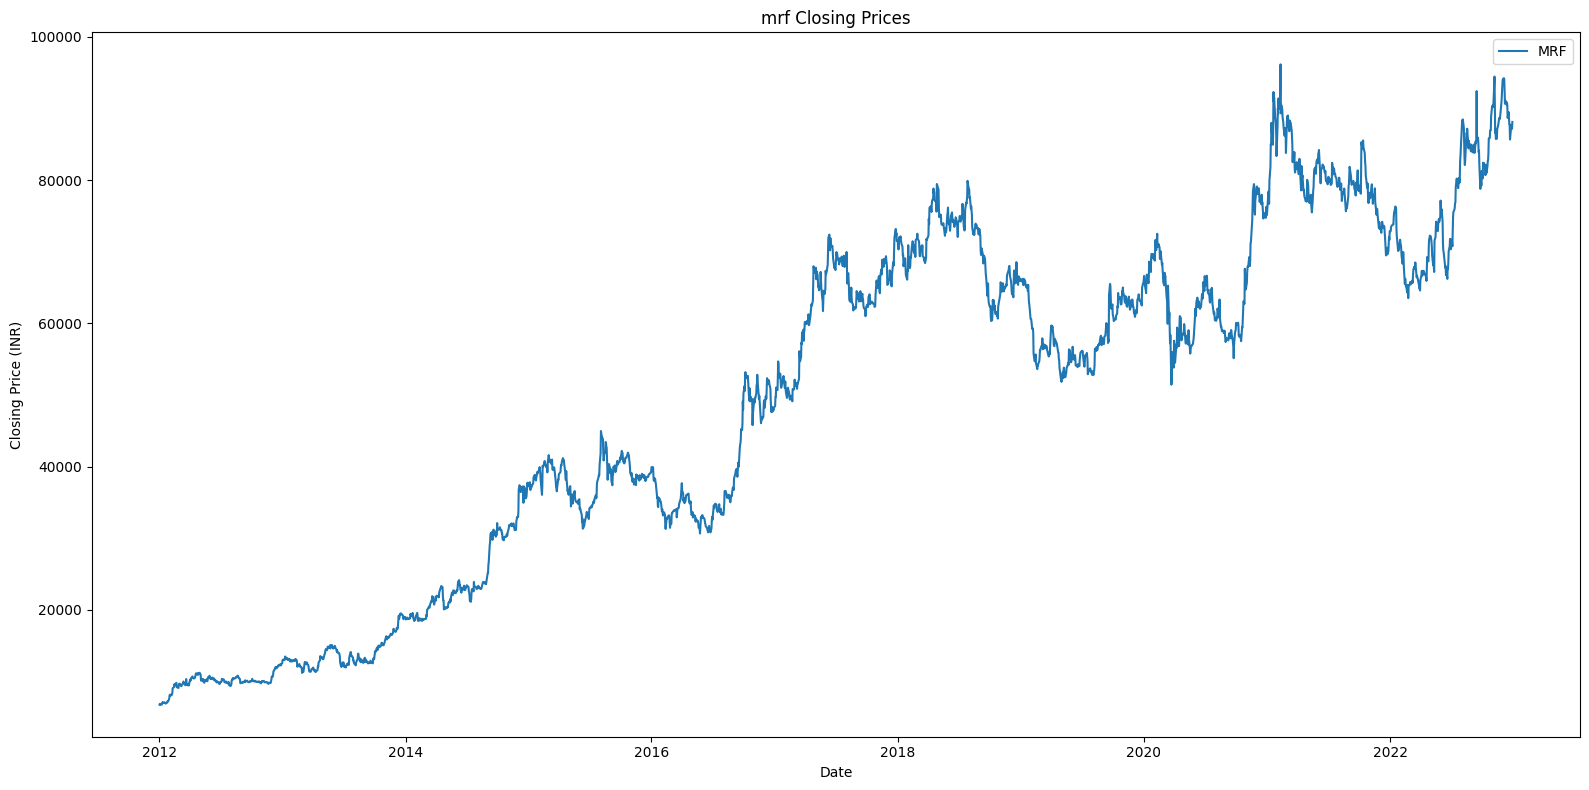

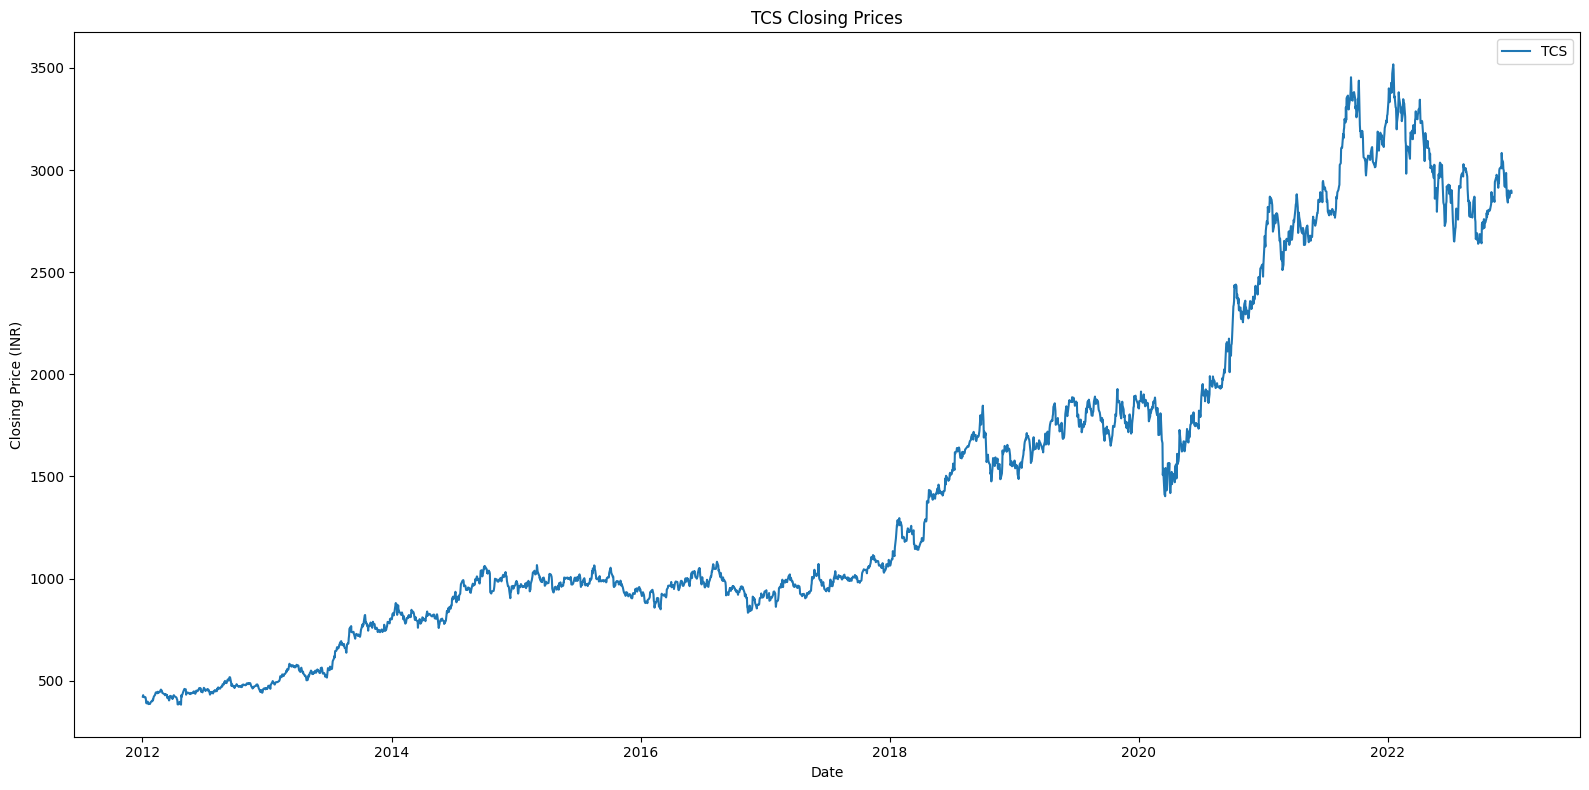

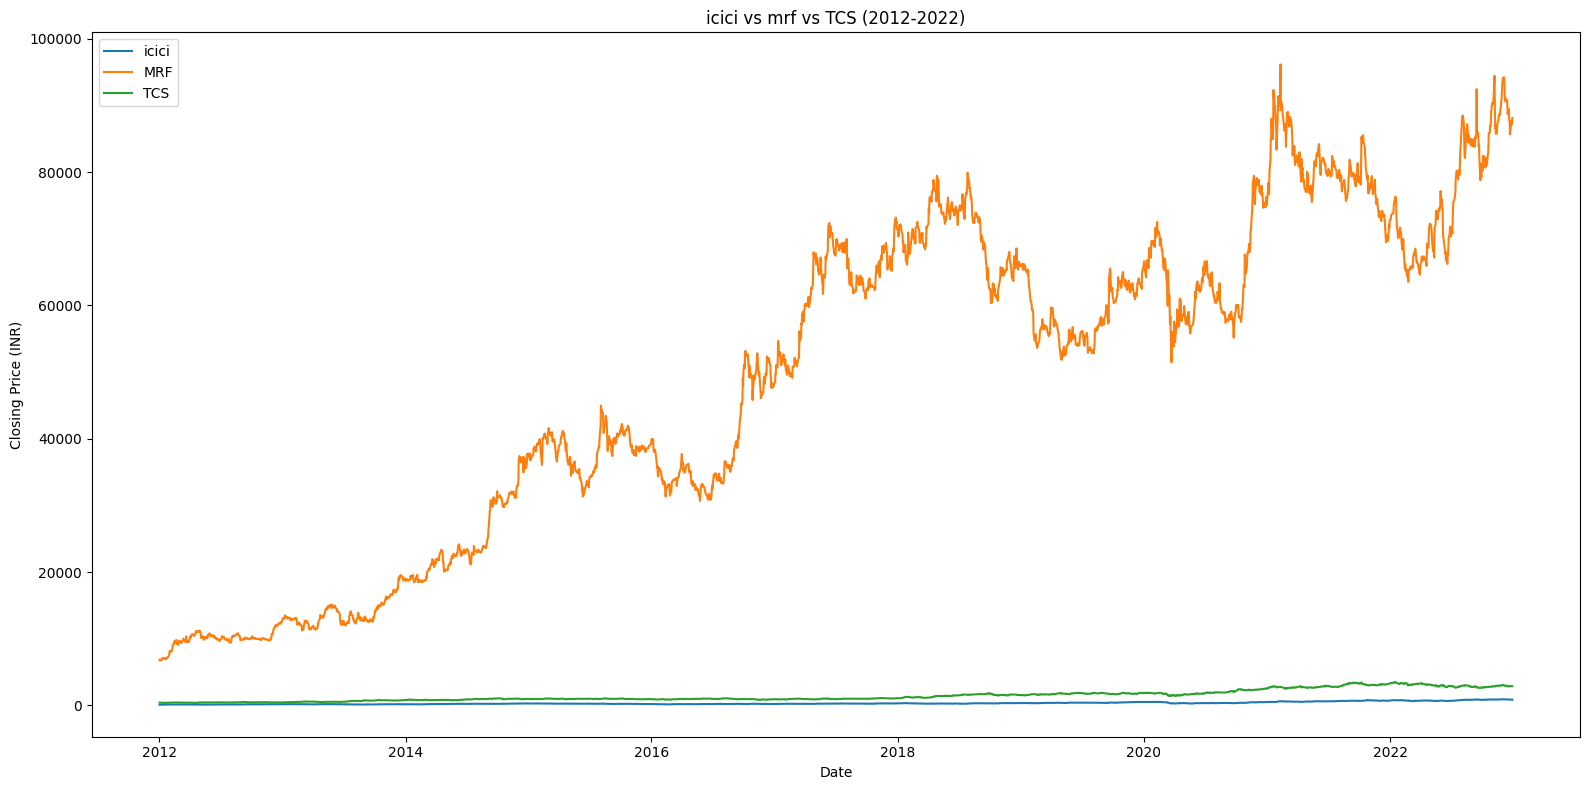

In [25]:
#stock ticker symbols
icici_symbol='ICICIBANK.NS'
mrf_symbol='MRF.NS'
tcs_symbol='TCS.NS'

start_date= '2012-01-01'
end_date='2022-12-31'

#download historical data
icici_data = download_historical_data(icici_symbol,start_date,end_date)
mrf_data = download_historical_data(mrf_symbol,start_date,end_date)
tcs_data = download_historical_data(tcs_symbol,start_date,end_date)

#plot each stock seperately
plt_closing_price(
    [icici_data],
    ["icici"],
    title="icici Closing Prices"
)

plt_closing_price(
    [mrf_data],
    ["MRF"],
    title="mrf Closing Prices"
)

plt_closing_price(
    [tcs_data],
    ["TCS"],
    title="TCS Closing Prices"
)

#plot all together
plt_closing_price(
    [icici_data, mrf_data, tcs_data],
    ["icici", "MRF", "TCS"],
    title="icici vs mrf vs TCS (2012-2022)"
)



### Technical Analysis

**Simple Moving Averages (SMA) and Exponential Moving Averages (EMA)**  
   - Plot the SMA and EMA of 5 days of each of the three stocks that you have selected.
   - SMA and EMA graph should be plotted on the same graph
   - Hence you have to plot three graphs of each stock with SMA and EMA
    

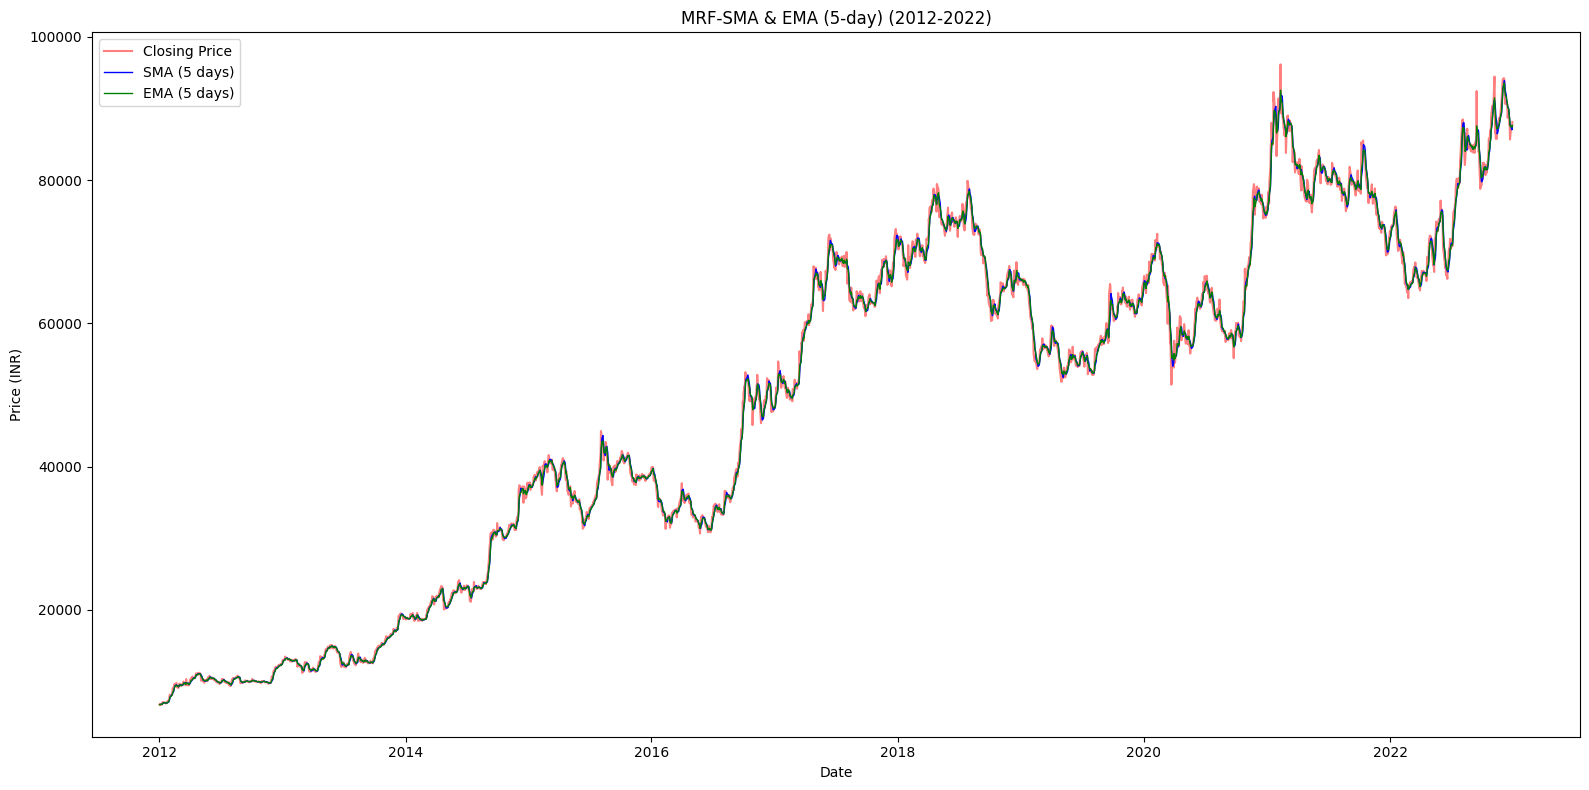

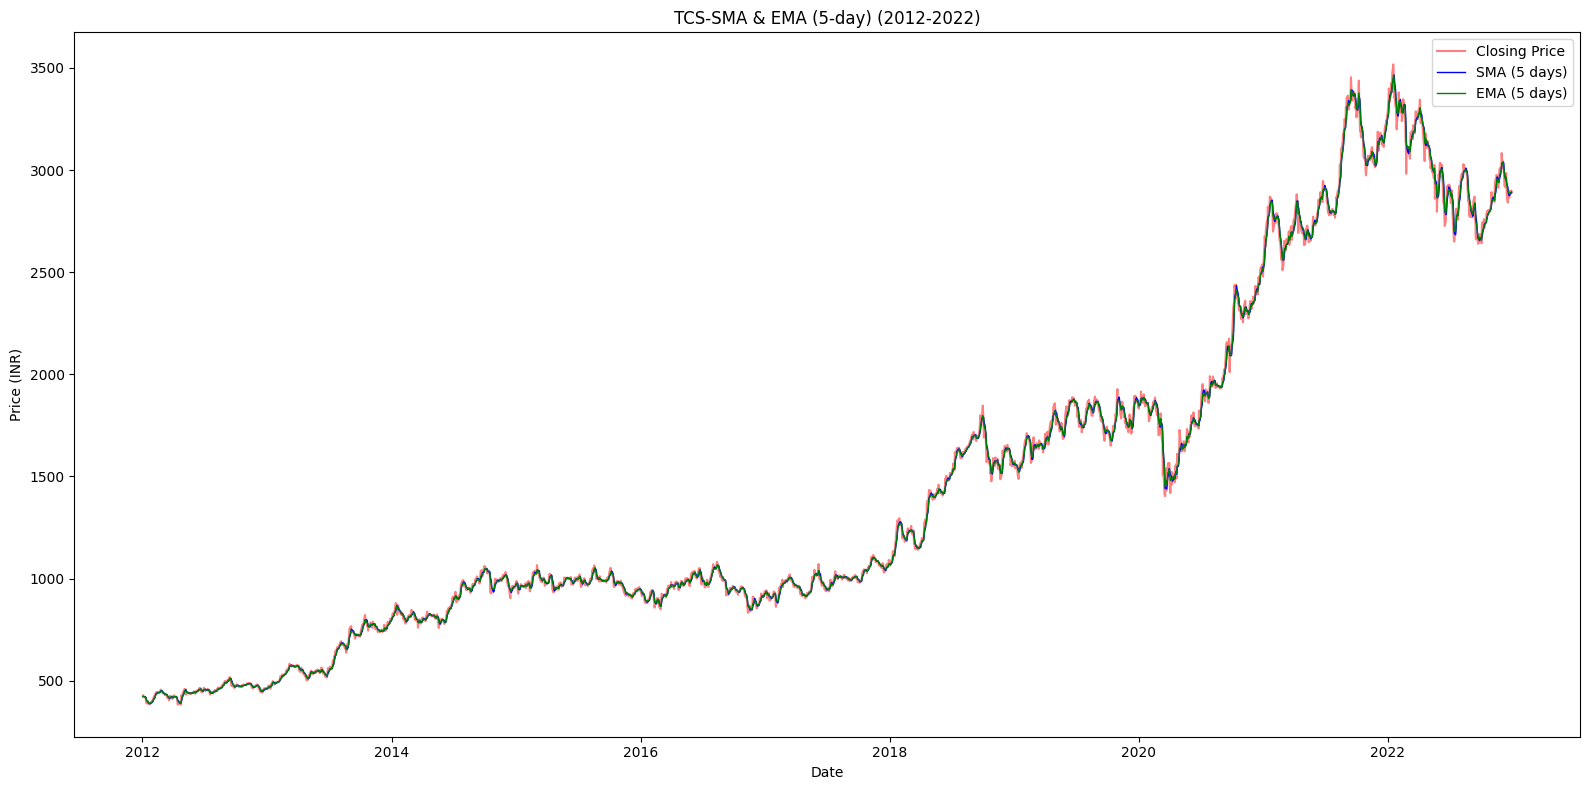

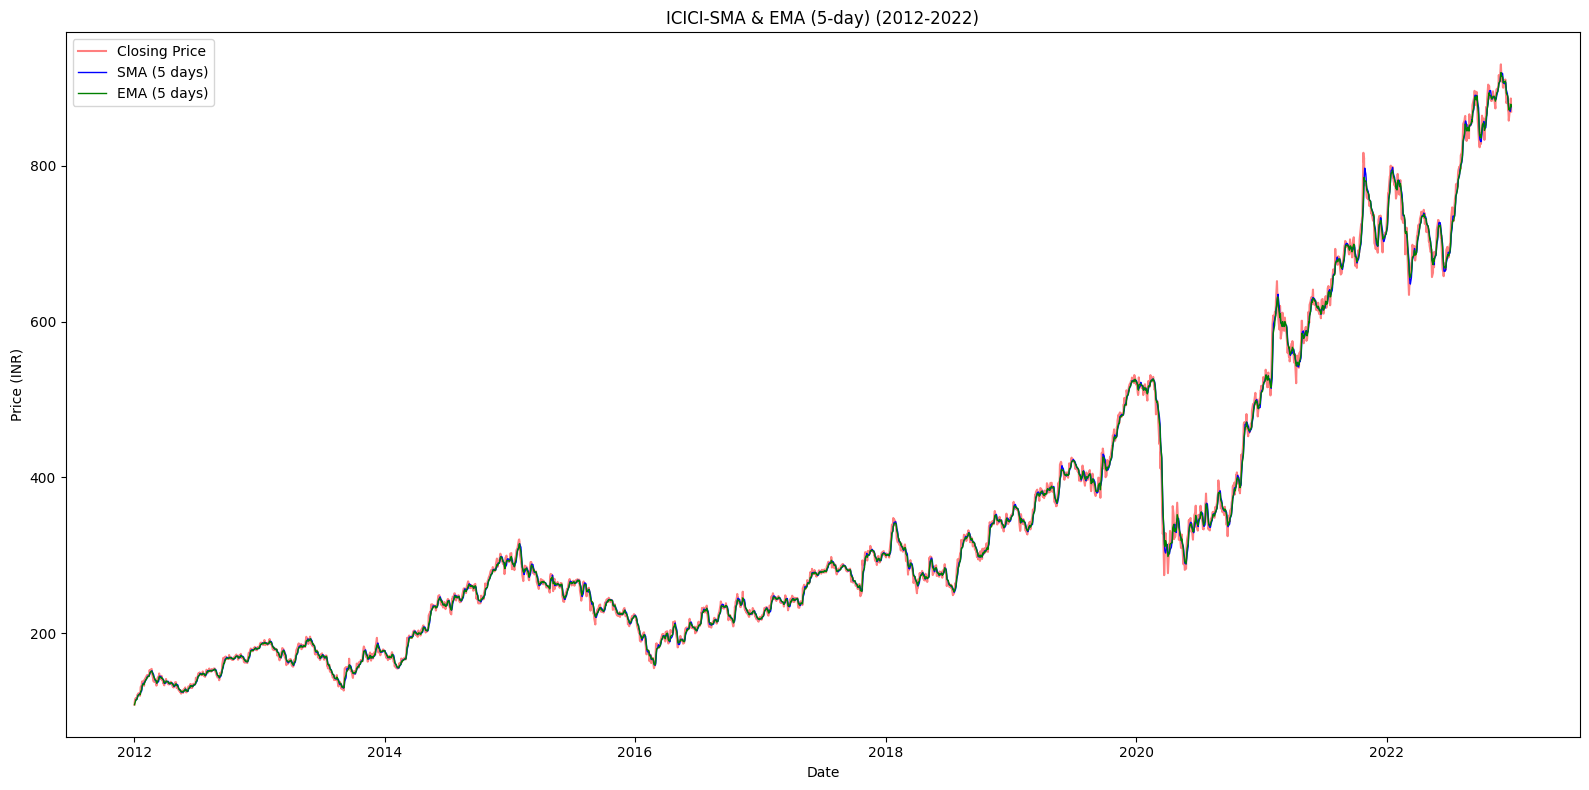

In [26]:
def plot_ema_sma(data,label,window=5):
    sma=data['Close'].rolling(window=window).mean()
    ema=data['Close'].ewm(span=window,adjust=False).mean()

    plt.figure(figsize=(16,8))
    plt.plot(data.index, data['Close'],label='Closing Price',alpha=0.5,color='red')
    plt.plot(data.index, sma, label=f'SMA ({window} days)', color='blue', linewidth=1)
    plt.plot(data.index, ema, label=f'EMA ({window} days)', color='green', linewidth=1)
    plt.title(f'{label}-SMA & EMA ({window}-day) (2012-2022)')
    plt.xlabel('Date')
    plt.ylabel('Price (INR)')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_ema_sma(mrf_data,"MRF")
plot_ema_sma(tcs_data,"TCS")
plot_ema_sma(icici_data,"ICICI")


**MACD**  
   - Plot MACD and Signal line for each of the three stocks.
   - Fast Length (Short-term EMA): 12 periods
   - Slow Length (Long-term EMA): 26 periods
   - Signal Line (Smoothing EMA): 9 periods

    

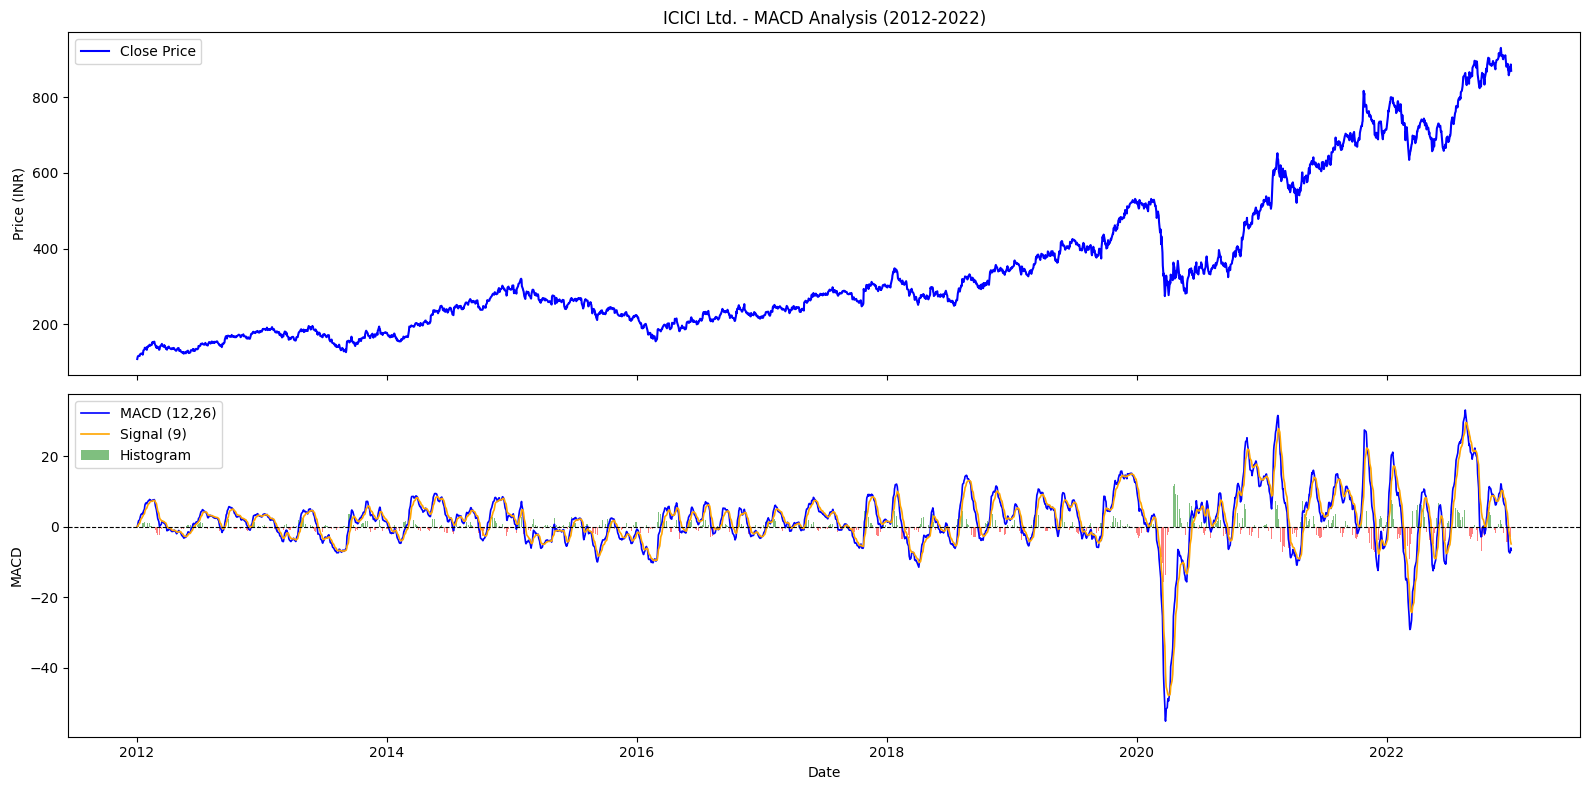

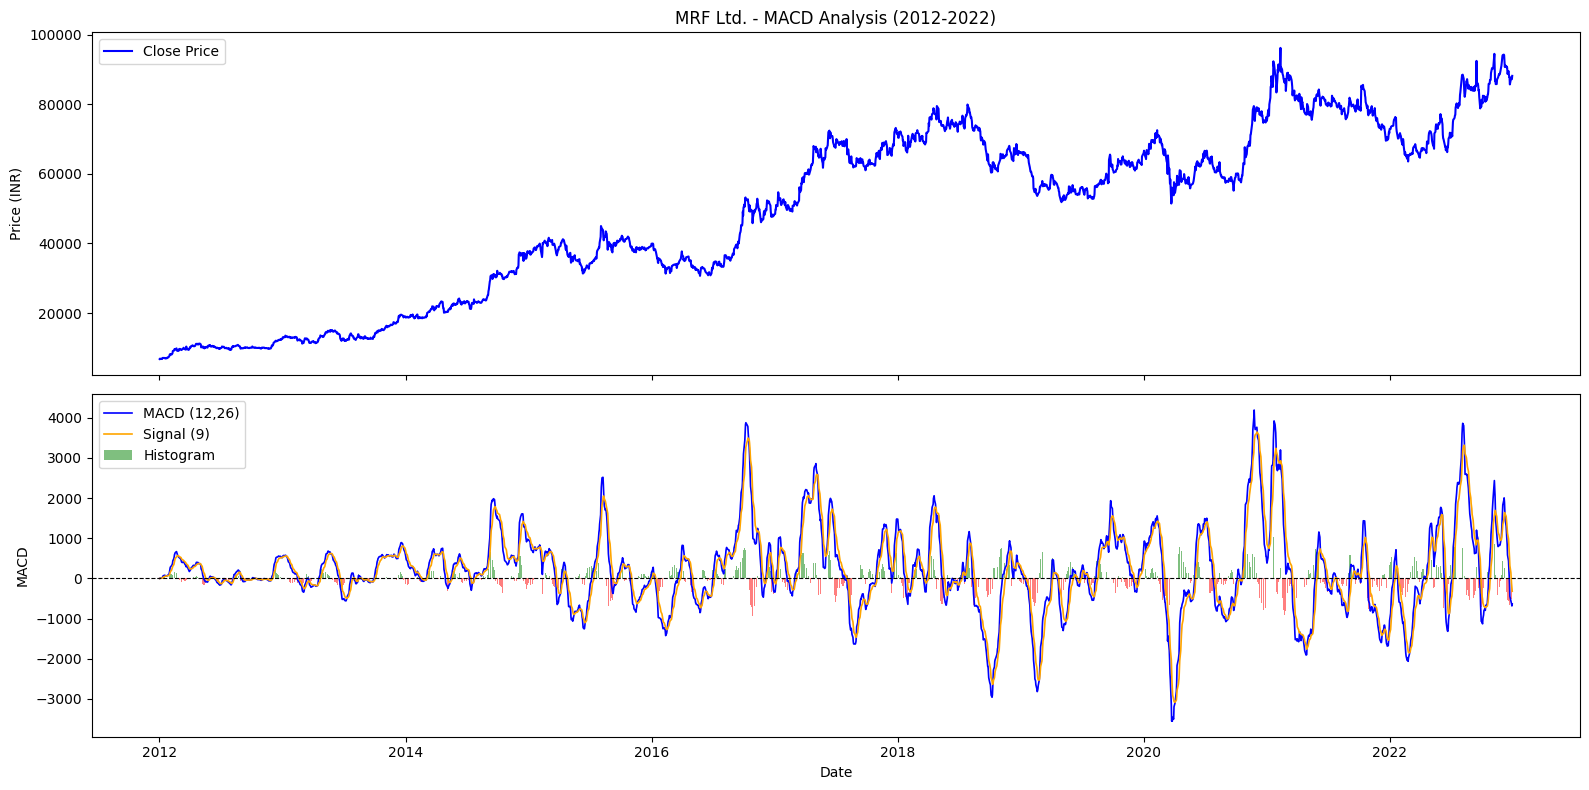

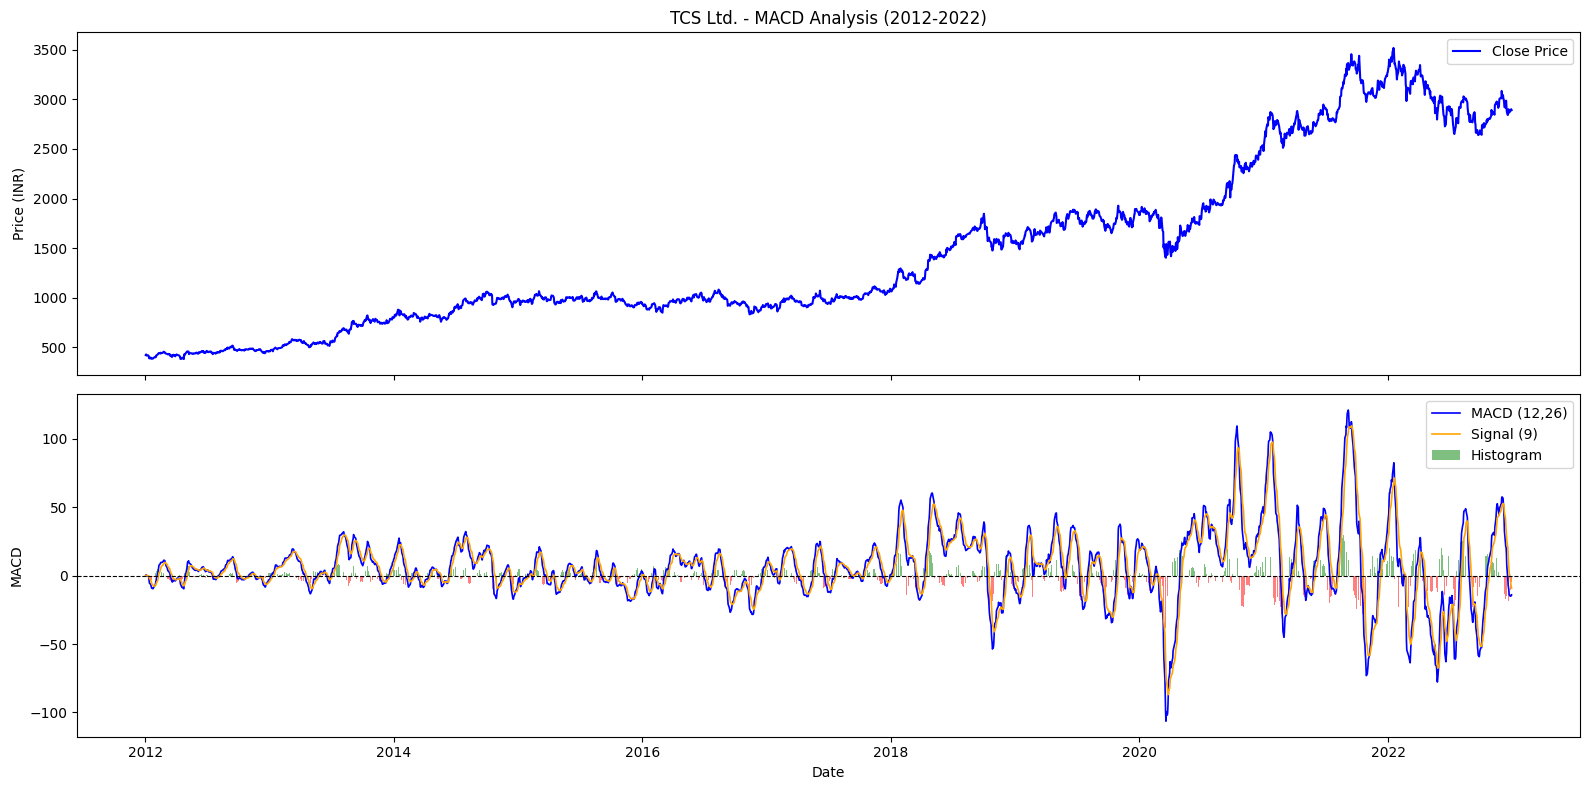

In [27]:
def plot_macd(data, label, fast=12,slow=26, signal=9):
    close = data['Close'].squeeze().astype(float)
    ema_fast = close.ewm(span=fast, adjust=False).mean()
    ema_slow = close.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    hist_values = histogram.values.astype(float)
    colors = ['green' if v >= 0 else 'red' for v in hist_values]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

    ax1.plot(data.index, close, label='Close Price', color='blue')
    ax1.set_title(f'{label} - MACD Analysis (2012-2022)')
    ax1.set_ylabel('Price (INR)')
    ax1.legend()

    ax2.plot(data.index, macd_line, label=f'MACD ({fast},{slow})', color='blue', linewidth=1.2)
    ax2.plot(data.index, signal_line, label=f'Signal ({signal})', color='orange', linewidth=1.2)
    ax2.bar(data.index, histogram, label='Histogram', color=colors, alpha=0.5)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('MACD')
    ax2.set_xlabel('Date')
    ax2.legend()

    plt.tight_layout()
    plt.show()

# Plot MACD for each stock
plot_macd(icici_data, 'ICICI Ltd.')
plot_macd(mrf_data, 'MRF Ltd.')
plot_macd(tcs_data, 'TCS Ltd.')

**RSI**  
   - Plot RSI for each of the three stocks
   - Period = 14 days
   - Also show the overbought and oversold regions
   - Overbought condition: RSI above 70
   - Oversold condition: RSI below 30
   
    

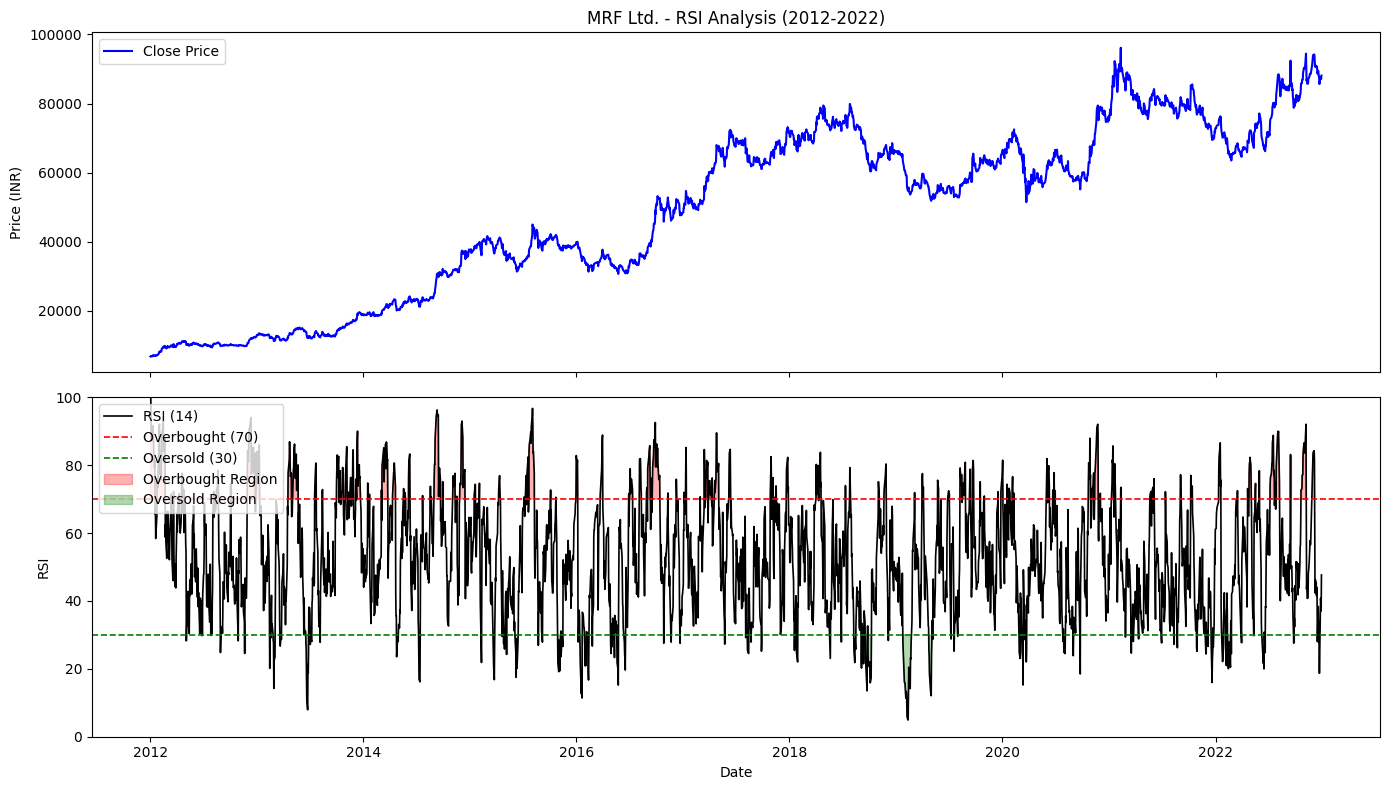

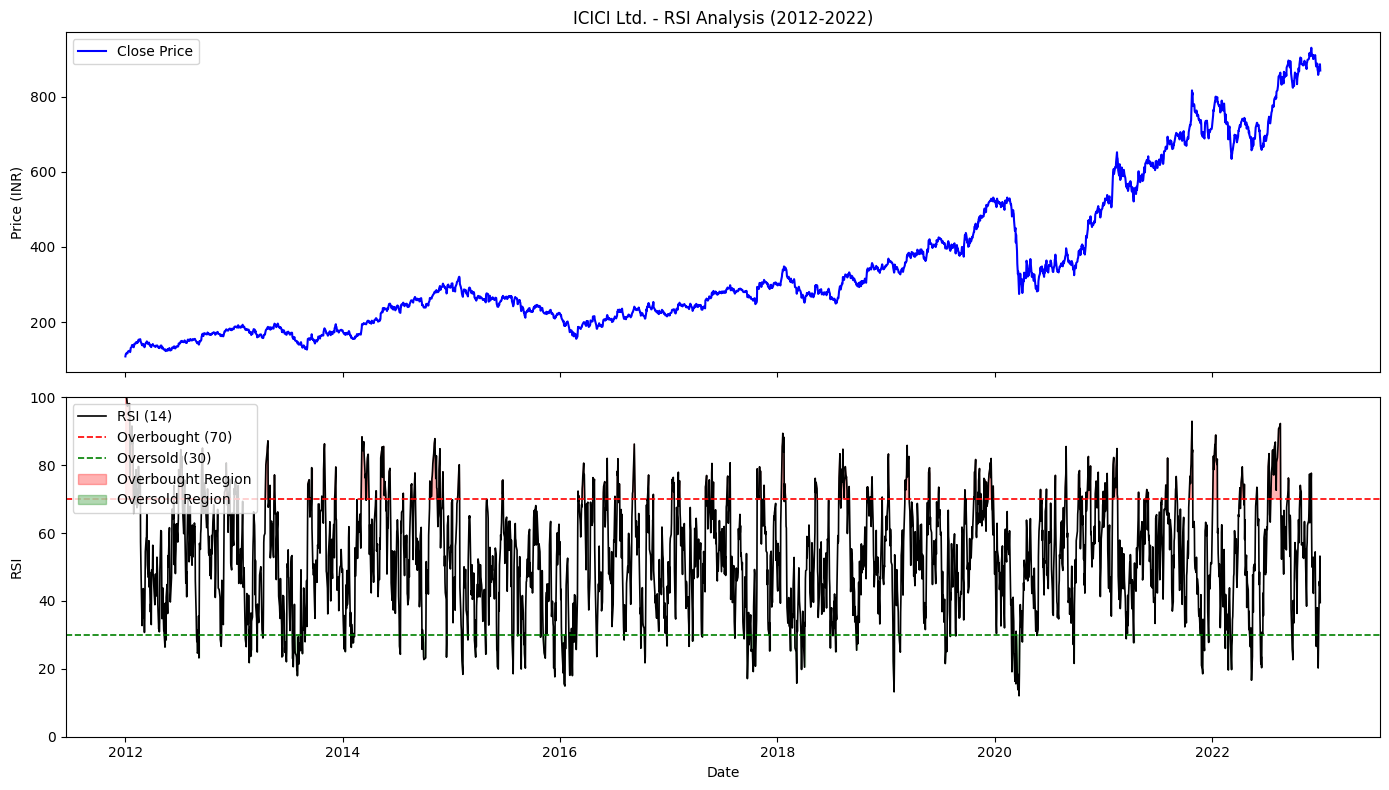

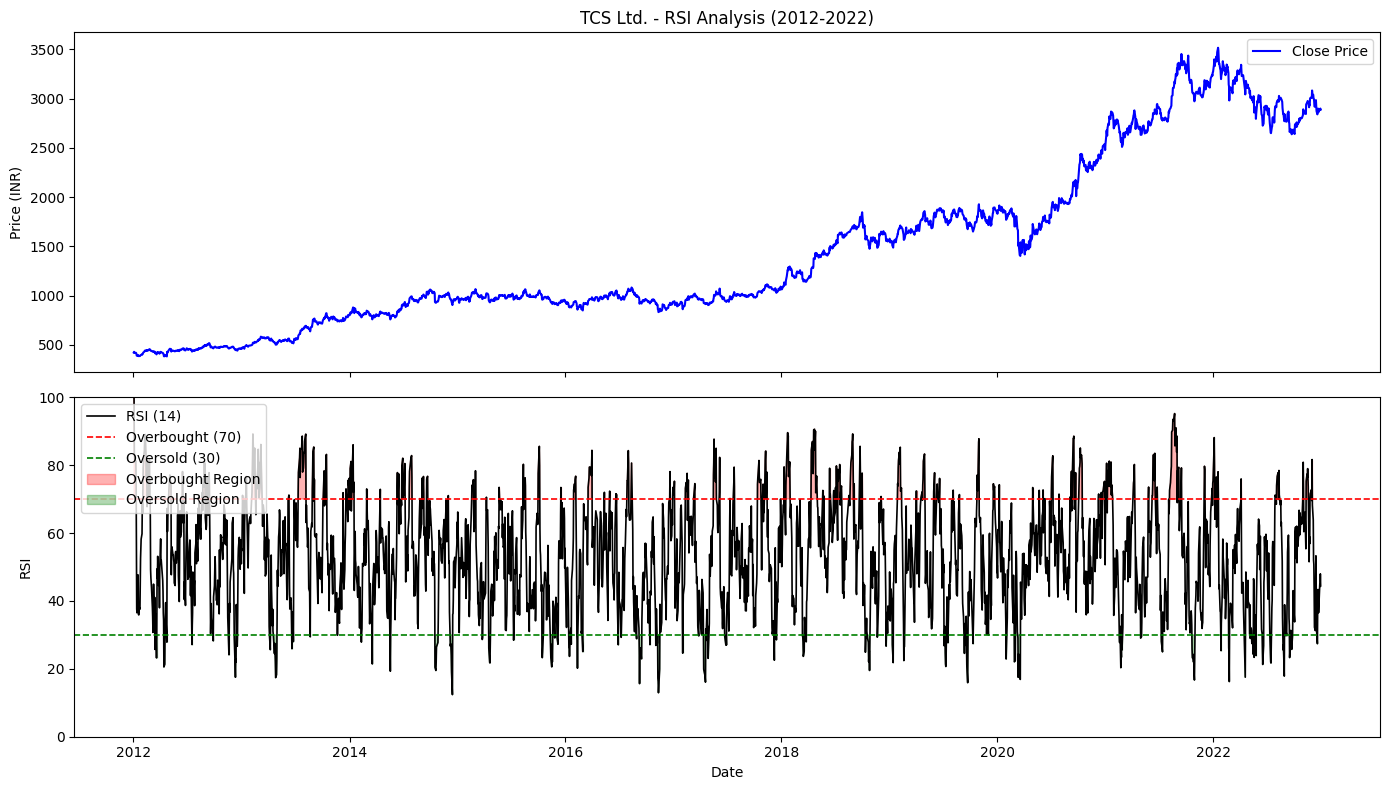

In [28]:
def plot_rsi(data, label, period=14):
    close = data['Close'].squeeze().astype(float)
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(span=period, adjust=False).mean()
    avg_loss = loss.ewm(span=period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax1.plot(data.index, close, label='Close Price', color='blue')
    ax1.set_title(f'{label} - RSI Analysis (2012-2022)')
    ax1.set_ylabel('Price (INR)')
    ax1.legend()

    ax2.plot(data.index, rsi, label=f'RSI ({period})', color='black', linewidth=1.2)
    ax2.axhline(70, color='red', linestyle='--', linewidth=1.2, label='Overbought (70)')
    ax2.axhline(30, color='green', linestyle='--', linewidth=1.2, label='Oversold (30)')
    ax2.fill_between(data.index, rsi, 70, where=(rsi >= 70), alpha=0.3, color='red', label='Overbought Region')
    ax2.fill_between(data.index, rsi, 30, where=(rsi <= 30), alpha=0.3, color='green', label='Oversold Region')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('RSI')
    ax2.set_xlabel('Date')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Plot RSI for each stock
plot_rsi(mrf_data, 'MRF Ltd.')
plot_rsi(icici_data, 'ICICI Ltd.')
plot_rsi(tcs_data, 'TCS Ltd.')

### Summarize your analysis

""""""
Summary of Technical Analysis: MRF, TCS, and ICICI BANK. (2012-2022)

=== mrf Ltd. (MRF.NS) ===
-Closing Price Trend: A strong, largely uninterrupted long-term uptrend across the decade — MRF is India's largest tyre maker and, since it has never split its stock or issued bonus shares, it carries the highest absolute share price on Indian exchanges (rising from roughly ₹8,000-9,000 in 2012 to well past ₹1,00,000 by 2022, a 10x+ move). The trend wasn't perfectly smooth: an auto-sector slowdown in 2018-2019 (NBFC crisis weighing on vehicle sales) caused a multi-quarter consolidation/correction, and the stock fell sharply in the broad March 2020 COVID crash before resuming its uptrend on strong replacement-tyre demand through 2020-2022.
-SMA & EMA (5-day): The short 5-day window kept SMA and EMA tracking closely with price for most of the decade, reflecting MRF's relatively low day-to-day volatility for a stock of its price. The EMA's faster reaction stood out at the two main turning points — the 2018-2019 slowdown and the March 2020 crash/recovery — leading the SMA in both directions.
-MACD: Gave a bullish crossover in April 2015, followed by another positive crossover in June 2015, kicking off a strong rally phase. The trend held through 2017-2018 before MACD turned bearish in August 2018, confirming the correction from ~₹80k to ~₹50k as an auto-sector slowdown. MACD gave a negative crossover again in February 2020, confirming the RSI divergence and the sharp fall from ~₹72k to ~₹50k into the COVID crash. It finally turned bullish in April 2020, and held through 2021-2022, confirming the renewed uptrend as replacement-tyre demand and pricing power drove the stock past its prior high
-RSI (14-day): Frequently pushed into overbought territory (>70) during the strong bull phases 2014-2015, 2017-2018, and again through 2021-2022 with a clear positive divergence in June 2015 aligning with that month's MACD bullish crossover. Oversold readings (<30) were comparatively rare and short-lived, showing up mainly during the 2018-2019 slowdown and the March 2020 crash — consistent with MRF's reputation. RSI flagged a negative divergence in February 2020 ahead of the steep fall to ~₹50k, then gave a positive divergence in March 2020  a month before MACD's bullish crossover confirmed it in April 2020  marking the bottom of the COVID correction.


=== ICICI BANK. (ICICI.NS) ===
-Closing Price Trend: ICICI Bank's closing price grew strongly over the decade, rising from around ₹125 in January 2012 to roughly ₹900 by 2022. The stock has been volatile, a gradual recovery through 2012-2014 gave way to a range-bound stretch from 2015-2018 as rising corporate NPAs hit Indian banks broadly, compounded by the 2018 Chanda Kochhar/Videocon governance controversy. The stock stabilized and re-rated from 2019 under new leadership and a cleaner balance sheet, before a sharp, sudden COVID-19 crash in early 2020 interrupted the uptrend followed by a strong recovery and sustained rally through 2020-2022.
-SMA & EMA (5-day): Given its volatile nature, the 5-day SMA and EMA were broken repeatedly throughout the period and far more often than for a steadier stock like TCS. As a banking-sector stock, ICICI tends to be among the first to react to shifts in the broader economy, so price typically broke below the EMA and SMA right at the start of each downturn (the 2015-2018 NPA stress years, the 2018 scandal, and the 2020 crash), with the more reactive EMA usually giving the earliest signal at these bottoms.
-MACD & RSI Divergences: The stock showed several clear divergence episodes between price and the MACD/RSI indicators, often flagging turning points before they showed up on the price chart alone. A strong negative divergence appeared around January 2015, preceding a correction tied to the building NPA stress. Positive divergences showed up around August-September 2013 and again around August 2016, with both RSI and MACD turning up ahead of, or alongside, price bottoming out on each occasion. The biggest instance came in 2019 where price formed a double top, but RSI and MACD both indicated a strong negative divergence against it, a bearish warning even while price held near its highs. That divergence played out in the sharp February-March 2020 COVID sell-off, after which MACD gave a clear positive crossover in April 2020, marking the start of the recovery

=== TCS Ltd. (TCS.NS) ===
-Closing Price Trend: TCS was the steadiest compounder of the three, consistent with its position as India's largest, most defensive IT services company. Rupee depreciation in 2013 aided margins; mild corrections hit in 2015-16 (global growth/Brexit jitters) and 2018 (US trade-policy and currency volatility). TCS fell sharply in the broad March 2020 COVID crash but staged one of the fastest V-shaped recoveries on record, riding the digital-transformation/cloud-spending boom through a strong 2020-2021 rally, before correcting in 2022 alongside the global tech sell-off and rate-hike cycle.
-SMA & EMA (5-day): Tracked closely for most of the decade given low volatility. TCS rarely broke its averages as compared to  ICICI. The EMA's responsiveness stood out specifically around the sharp March 2020 crash/rebound and the 2022 correction, where it dipped below the SMA ahead of price confirming the downturn.
-MACD: Crossovers were comparatively low through 2012-2019, with only a mild bearish dip ahead of the 2018 correction. The COVID crash produced a sharp bearish dip in March 2020, followed by one of the strongest bullish crossovers of the decade as the 2020-2021 rally took hold. A clear bearish crossover/divergence reappeared in 2022 — price pushed to fresh highs while MACD failed to confirm — preceding that year's correction.
-RSI (14-day): Extreme readings were rare given the stock's stability. Brief oversold dips appeared in the 2015-16 correction and the March 2020 crash. Overbought conditions (>70) were most pronounced during 2017 and especially through the 2020-2021 digital-demand rally. Into 2022, RSI failed to make new highs alongside price — a bearish divergence that foreshadowed the correction.

TCS and MRF have steadily grown across the decade with lower signals in comaprision to ICICI bank due to its volatile nature. The more volatile the stock, the more often the RSI/MACD indicators gave signals. For a steadier stock like MRG, a signal is rarer and more reliable whereas for ICICI, signals came in more often and need more monitoring

""""""